# Results Visualization and Reporting

This notebook creates comprehensive visualizations and reports for the churn prediction model results, answering key business questions about customer churn.

## Business Questions Addressed:

1. **Who are our highest-risk customers?** - Risk scoring analysis and customer segmentation
2. **What drives churn most?** - Feature importance and SHAP analysis
3. **How accurate is this?** - Model performance metrics and validation
4. **What should we do?** - Actionable insights and recommendations
5. **How do we use this?** - Production-ready outputs and deployment guidance

In [2]:
# Install required packages
# %pip install pandas matplotlib seaborn plotly

# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [3]:
# Configuration
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# Load test data for detailed analysis
print("=== Loading Test Data ===")

# Use engineered features if available, otherwise fall back to basic processed data
engineered_test_path = PROCESSED_DIR / "test_engineered.parquet"

if engineered_test_path.exists():
    print("Using engineered features...")
    X_test = pd.read_parquet(engineered_test_path)
else:
    print("Using basic processed features...")
    X_test = pd.read_parquet(PROCESSED_DIR / "test.parquet")

y_test = pd.read_parquet(PROCESSED_DIR / "test_labels.parquet").squeeze()

customer_id_test = X_test['customerID']

=== Loading Test Data ===
Using engineered features...


In [5]:
# Load model comparison results
print("=== Loading Model Results ===")

results_path = MODELS_DIR / "model_comparison_results.csv"
if results_path.exists():
    results_df = pd.read_csv(results_path, index_col=0)
    print("Model comparison results loaded:")
    print(results_df.round(4))
else:
    print("Warning: Model comparison results not found. Creating placeholder...")
    # Create placeholder results if file doesn't exist
    results_df = pd.DataFrame({
        'train_accuracy': [0.80, 0.85, 0.83],
        'test_accuracy': [0.79, 0.78, 0.79],
        'train_precision': [0.65, 0.70, 0.68],
        'test_precision': [0.62, 0.61, 0.63],
        'train_recall': [0.55, 0.60, 0.58],
        'test_recall': [0.52, 0.50, 0.51],
        'train_f1': [0.60, 0.65, 0.62],
        'test_f1': [0.56, 0.54, 0.56],
        'train_roc_auc': [0.85, 0.88, 0.86],
        'test_roc_auc': [0.83, 0.83, 0.84]
    }, index=['Logistic Regression', 'Random Forest', 'Gradient Boosting'])

# Load test data for detailed analysis
print("=== Loading Test Data ===")

# Use engineered features if available, otherwise fall back to basic processed data
engineered_test_path = PROCESSED_DIR / "test_engineered.parquet"

if engineered_test_path.exists():
    print("Using engineered features...")
    X_test = pd.read_parquet(engineered_test_path)
else:
    print("Using basic processed features...")
    X_test = pd.read_parquet(PROCESSED_DIR / "test.parquet")

y_test = pd.read_parquet(PROCESSED_DIR / "test_labels.parquet").squeeze()

customer_id_test = X_test['customerID']

=== Loading Model Results ===
Model comparison results loaded:
                                train_accuracy  test_accuracy  \
model                                                           
Logistic Regression                     0.8089         0.7925   
Random Forest                           1.0000         0.7761   
Gradient Boosting                       0.8372         0.7953   
Logistic Regression (balanced)          0.7554         0.7328   
Random Forest (balanced)                0.9989         0.7669   
Gradient Boosting (balanced)            0.7945         0.7328   
XGBoost                                 0.9897         0.7669   
XGBoost (balanced)                      0.9838         0.7534   
LightGBM                                0.9243         0.7804   
LightGBM (balanced)                     0.9022         0.7477   

                                train_precision  test_precision  train_recall  \
model                                                                      

=== Radar Chart Comparison ===


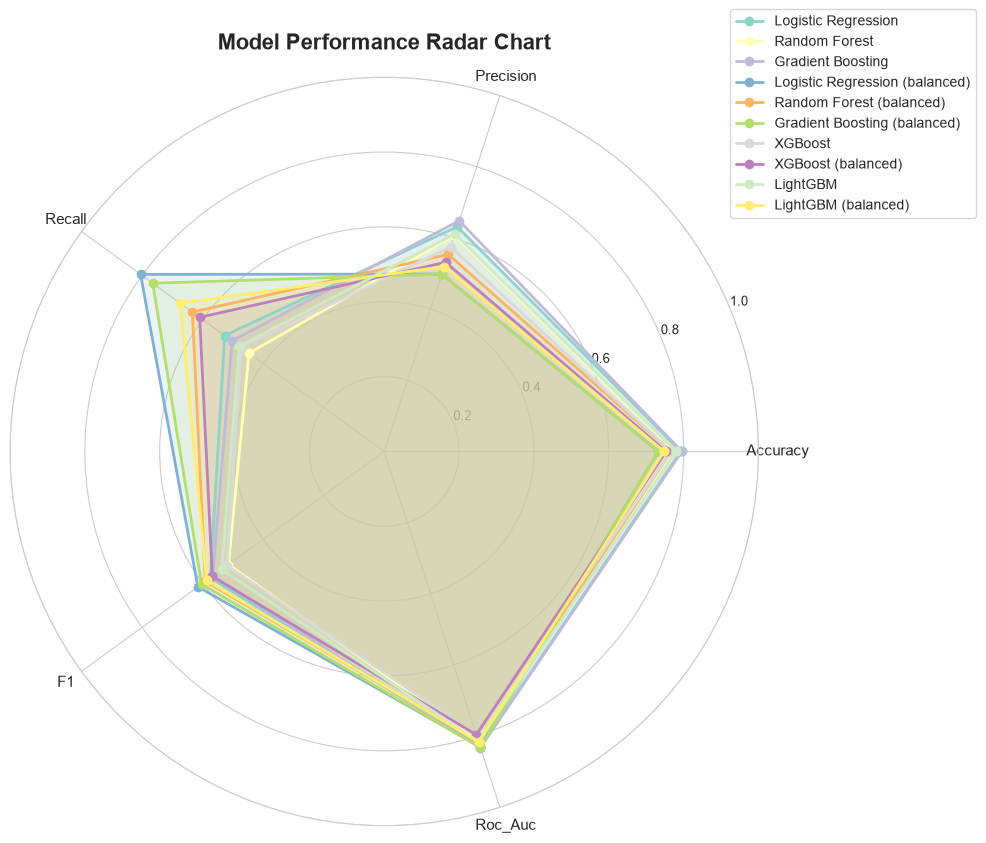

Radar chart saved to: ../results/model_radar_chart.png


In [6]:
# Radar chart for model comparison
print("=== Radar Chart Comparison ===")

from math import pi

# Select metrics for radar chart
metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc']
model_names = results_df.index.tolist()

# Number of variables
N = len(metrics)

# Compute angle for each axis
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Complete the circle

# Create radar chart
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

colors = plt.cm.Set3(np.linspace(0, 1, len(model_names)))

for idx, model in enumerate(model_names):
    values = results_df.loc[model, metrics].values.flatten().tolist()
    values += values[:1]  # Complete the circle
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels([m.replace('test_', '').title() for m in metrics], fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
ax.set_title('Model Performance Radar Chart', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Radar chart saved to: {RESULTS_DIR / 'model_radar_chart.png'}")

In [7]:
# Load best model and create detailed analysis
print("=== Loading Best Model ===")

best_model_name = results_df['test_roc_auc'].idxmax()
print(f"Best model: {best_model_name}")

best_model_path = MODELS_DIR / f"{best_model_name.lower().replace(' ', '_')}.pkl"
with open(best_model_path, 'rb') as f:
    best_model = pickle.load(f)

print(f"Loaded model from: {best_model_path}")

=== Loading Best Model ===
Best model: Gradient Boosting
Loaded model from: ../models/gradient_boosting.pkl


In [8]:
# Load best model and create detailed analysis
print("=== Loading Best Model ===")

best_model_name = results_df['test_roc_auc'].idxmax()
print(f"Best model: {best_model_name}")

best_model_path = MODELS_DIR / f"{best_model_name.lower().replace(' ', '_')}.pkl"
with open(best_model_path, 'rb') as f:
    best_model = pickle.load(f)

print(f"Loaded model from: {best_model_path}")

# Load test data for detailed analysis
print("=== Loading Test Data ===")

# Use engineered features if available, otherwise fall back to basic processed data
engineered_test_path = PROCESSED_DIR / "test_engineered.parquet"

if engineered_test_path.exists():
    print("Using engineered features...")
    X_test = pd.read_parquet(engineered_test_path)
else:
    print("Using basic processed features...")
    X_test = pd.read_parquet(PROCESSED_DIR / "test.parquet")

y_test = pd.read_parquet(PROCESSED_DIR / "test_labels.parquet").squeeze()

# Remove customerID for prediction, keep for analysis
customer_id_test = X_test['customerID'].values
X_test_features = X_test.drop(columns=['customerID'])

print(f"Test features: {X_test_features.shape}")
print(f"Test labels: {y_test.shape}")
print(f"Customer IDs: {customer_id_test.shape}")

# Generate predictions and create analysis dataframe
print("=== Generating Predictions ===")

from sklearn.metrics import roc_auc_score, roc_curve

# Use the model to make predictions
y_test_pred = best_model.predict(X_test_features)
y_test_proba = best_model.predict_proba(X_test_features)[:, 1]

print(f"Predictions shape: {y_test_pred.shape}")
print(f"Probabilities shape: {y_test_proba.shape}")

# Debug: Check lengths before creating dataframe
print(f"Debug - customer_id_test length: {len(customer_id_test)}")
print(f"Debug - y_test length: {len(y_test)}")
print(f"Debug - y_test_pred length: {len(y_test_pred)}")
print(f"Debug - y_test_proba length: {len(y_test_proba)}")

# Ensure all arrays have the same length
min_length = min(len(customer_id_test), len(y_test), len(y_test_pred), len(y_test_proba))
print(f"Using minimum length: {min_length}")

# Truncate to minimum length to ensure consistency
customer_id_test = customer_id_test[:min_length]
y_test = y_test.iloc[:min_length] if hasattr(y_test, 'iloc') else y_test[:min_length]
y_test_pred = y_test_pred[:min_length]
y_test_proba = y_test_proba[:min_length]

# Create analysis dataframe with consistent indexing
analysis_df = pd.DataFrame({
    'customerID': customer_id_test,
    'actual_churn': y_test,
    'predicted_churn': y_test_pred,
    'churn_probability': y_test_proba
})

print(f"Analysis dataframe shape: {analysis_df.shape}")
print(analysis_df.head())

=== Loading Best Model ===
Best model: Gradient Boosting
Loaded model from: ../models/gradient_boosting.pkl
=== Loading Test Data ===
Using engineered features...
Test features: (1407, 77)
Test labels: (1407,)
Customer IDs: (1407,)
=== Generating Predictions ===
Predictions shape: (1407,)
Probabilities shape: (1407,)
Debug - customer_id_test length: 1407
Debug - y_test length: 1407
Debug - y_test_pred length: 1407
Debug - y_test_proba length: 1407
Using minimum length: 1407
Analysis dataframe shape: (1407, 4)
      customerID  actual_churn  predicted_churn  churn_probability
2481  6614-YWYSC             0                0           0.018860
6784  9546-KDTRB             0                0           0.069958
6125  0871-URUWO             1                1           0.697873
3052  5151-HQRDG             0                0           0.106499
4099  6624-JDRDS             0                0           0.232660


In [9]:
# Generate predictions and create analysis dataframe
print("=== Generating Predictions ===")

from sklearn.metrics import roc_auc_score, roc_curve

y_test_pred = best_model.predict(X_test_features)
y_test_proba = best_model.predict_proba(X_test_features)[:, 1]

# Create analysis dataframe
analysis_df = pd.DataFrame({
    'customerID': customer_id_test,
    'actual_churn': y_test,
    'predicted_churn': y_test_pred,
    'churn_probability': y_test_proba
})

print(f"Analysis dataframe shape: {analysis_df.shape}")
print(analysis_df.head())

=== Generating Predictions ===
Analysis dataframe shape: (1407, 4)
      customerID  actual_churn  predicted_churn  churn_probability
2481  6614-YWYSC             0                0           0.018860
6784  9546-KDTRB             0                0           0.069958
6125  0871-URUWO             1                1           0.697873
3052  5151-HQRDG             0                0           0.106499
4099  6624-JDRDS             0                0           0.232660


=== Prediction Probability Distribution ===


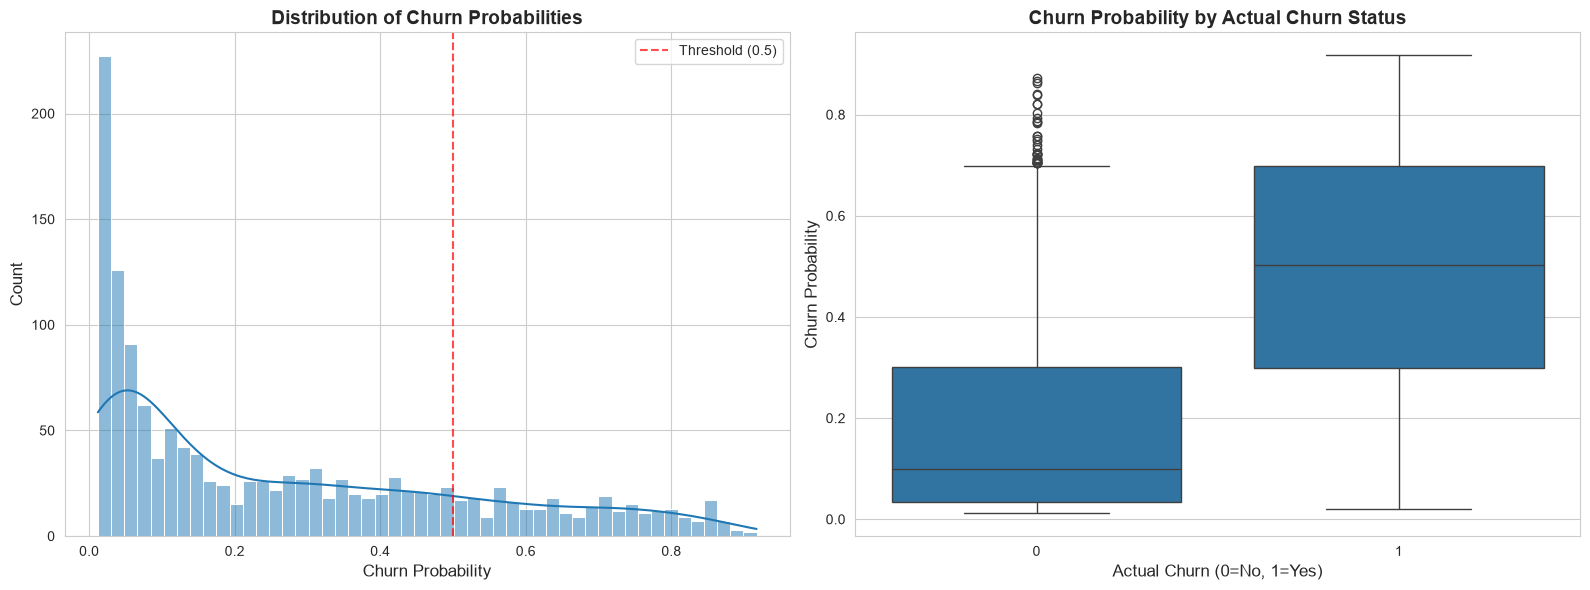

Probability distribution saved to: ../results/probability_distribution.png


In [10]:
# Prediction probability distribution
print("=== Prediction Probability Distribution ===")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall probability distribution
sns.histplot(data=analysis_df, x='churn_probability', bins=50, ax=axes[0], kde=True)
axes[0].set_title('Distribution of Churn Probabilities', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn Probability', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Threshold (0.5)')
axes[0].legend()

# Probability distribution by actual churn
sns.boxplot(data=analysis_df, x='actual_churn', y='churn_probability', ax=axes[1])
axes[1].set_title('Churn Probability by Actual Churn Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Actual Churn (0=No, 1=Yes)', fontsize=12)
axes[1].set_ylabel('Churn Probability', fontsize=12)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'probability_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Probability distribution saved to: {RESULTS_DIR / 'probability_distribution.png'}")

=== Confusion Matrix Analysis ===


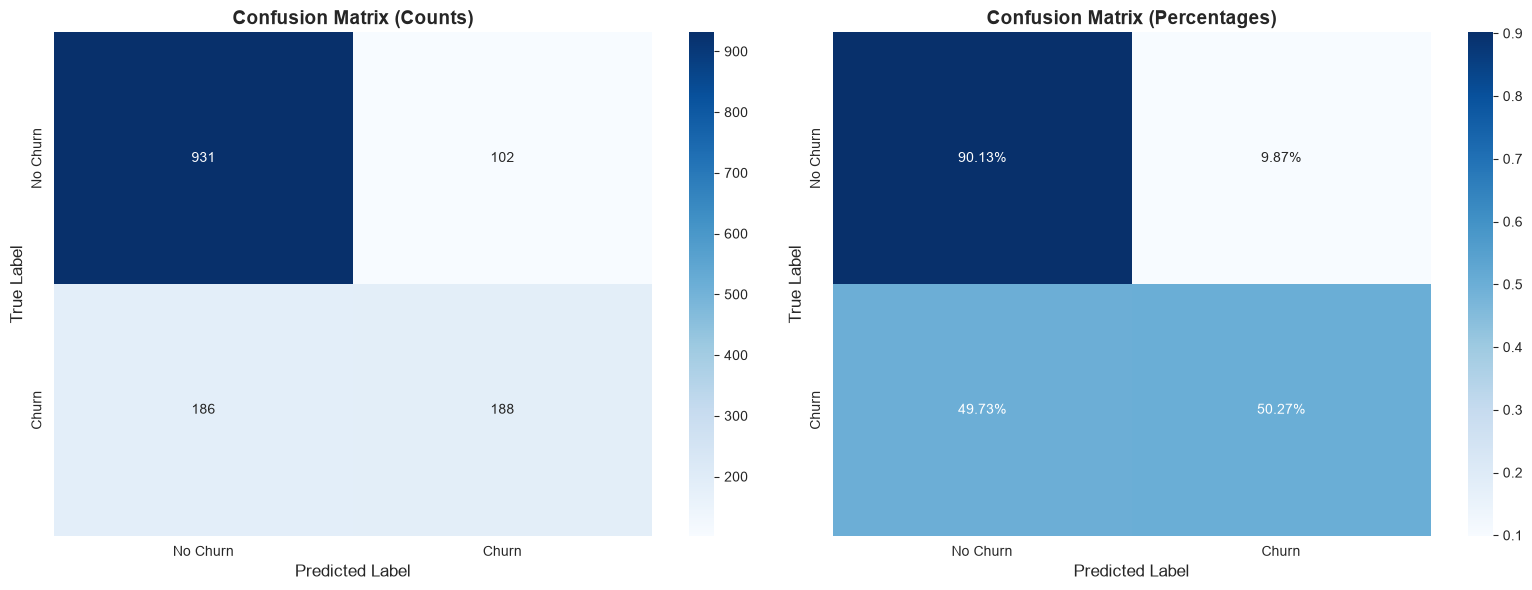

Confusion matrix saved to: ../results/confusion_matrix.png

Confusion Matrix Summary:
True Negatives: 931 (90.13%)
False Positives: 102 (9.87%)
False Negatives: 186 (49.73%)
True Positives: 188 (50.27%)


In [11]:
# Confusion Matrix with percentages
print("=== Confusion Matrix Analysis ===")

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Percentages
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Confusion matrix saved to: {RESULTS_DIR / 'confusion_matrix.png'}")
print(f"\nConfusion Matrix Summary:")
print(f"True Negatives: {cm[0, 0]} ({cm_normalized[0, 0]:.2%})")
print(f"False Positives: {cm[0, 1]} ({cm_normalized[0, 1]:.2%})")
print(f"False Negatives: {cm[1, 0]} ({cm_normalized[1, 0]:.2%})")
print(f"True Positives: {cm[1, 1]} ({cm_normalized[1, 1]:.2%})")

=== ROC Curve Analysis ===


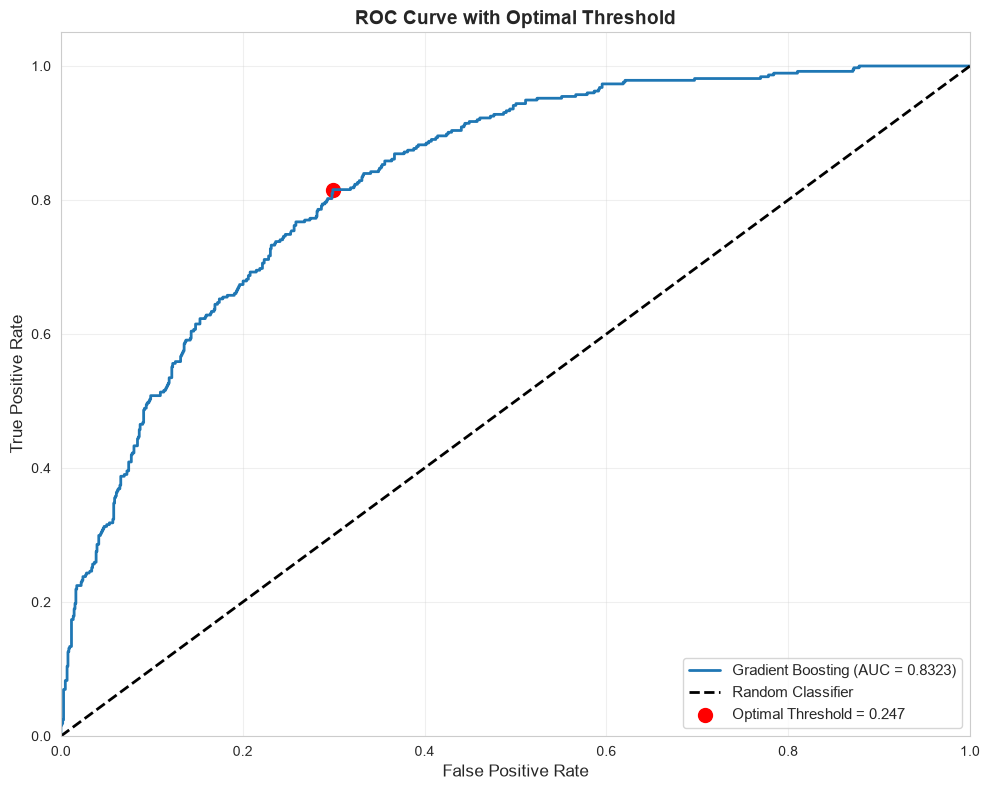

ROC curve saved to: ../results/roc_curve.png
Optimal threshold: 0.2475
ROC-AUC: 0.8323


In [12]:
# ROC Curve with optimal threshold
print("=== ROC Curve Analysis ===")

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

# Find optimal threshold (Youden's J statistic)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, linewidth=2, label=f'{best_model_name} (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', s=100, 
            label=f'Optimal Threshold = {optimal_threshold:.3f}')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve with Optimal Threshold', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

# Pass a tuple (instead of a list) to match the expected type.
plt.xlim((0, 1))
plt.ylim((0, 1.05))

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"ROC curve saved to: {RESULTS_DIR / 'roc_curve.png'}")
print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

=== Feature Importance Analysis ===


/var/folders/dn/wtcqyjbd1hn63s40771sdddm0000gn/T/ipykernel_93202/594136625.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top_features, ax=axes[0], palette='viridis')


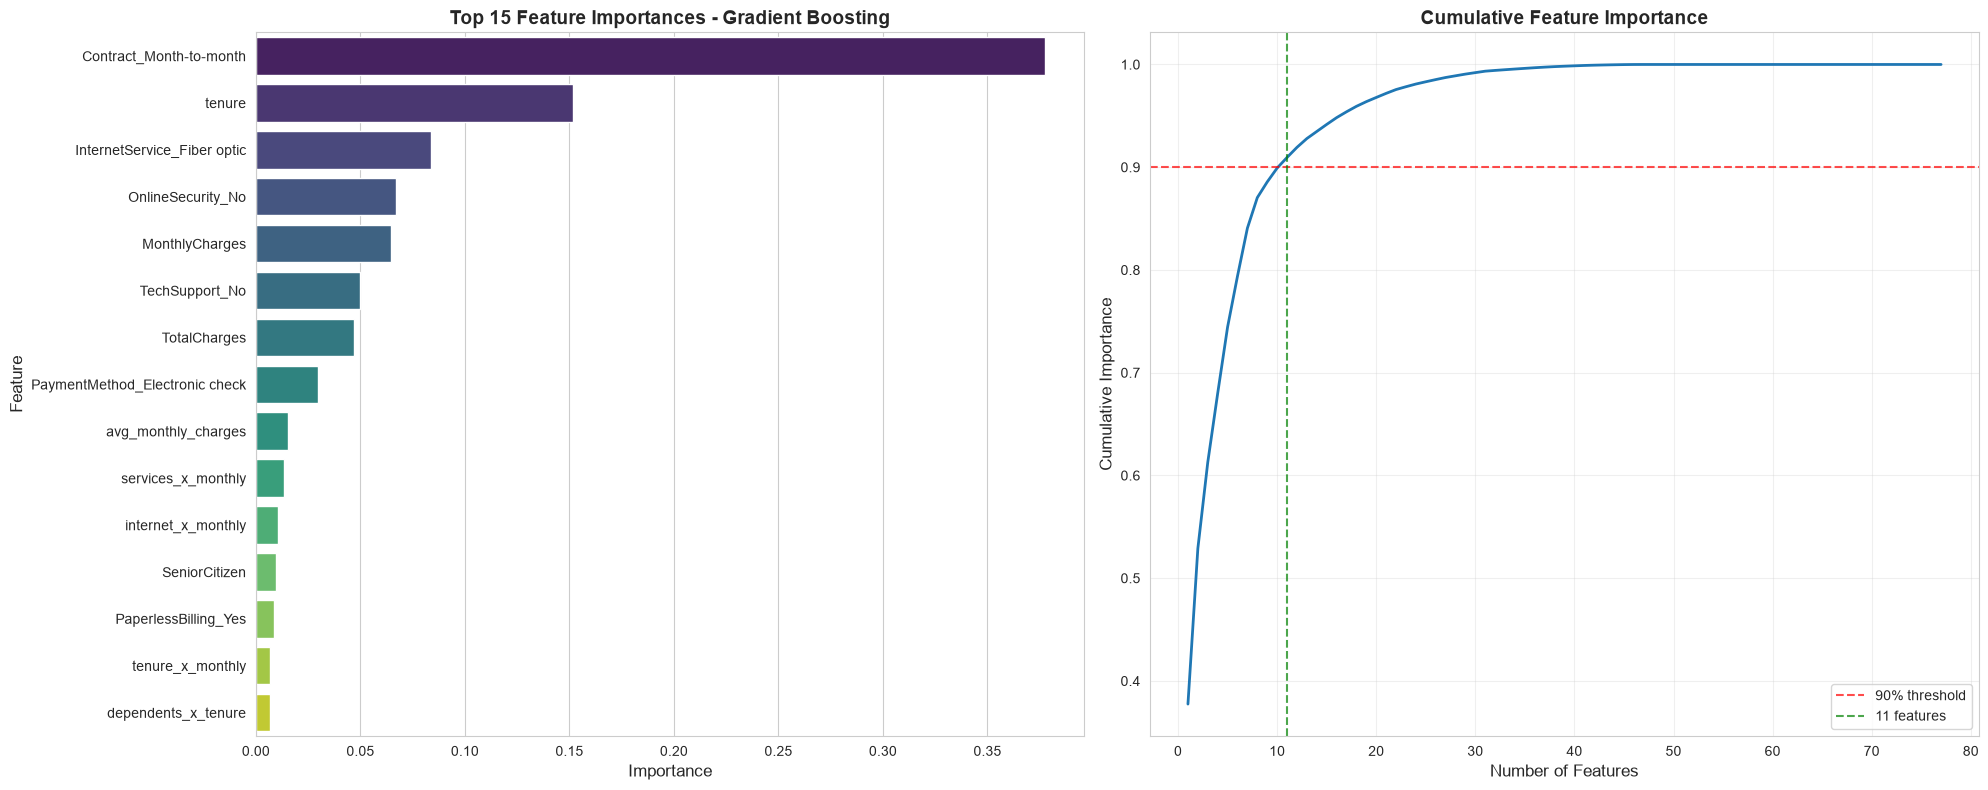

Feature importance saved to: ../results/feature_importance.png

Top 10 features:
                       feature  importance
       Contract_Month-to-month    0.377478
                        tenure    0.151492
   InternetService_Fiber optic    0.083812
             OnlineSecurity_No    0.067045
                MonthlyCharges    0.064594
                TechSupport_No    0.049566
                  TotalCharges    0.046713
PaymentMethod_Electronic check    0.029720
           avg_monthly_charges    0.015260
            services_x_monthly    0.013481

11 features explain 90% of the importance


In [13]:
# Feature importance visualization
print("=== Feature Importance Analysis ===")

if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_test_features.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Top 15 features
    top_features = feature_importance.head(15)
    sns.barplot(x='importance', y='feature', data=top_features, ax=axes[0], palette='viridis')
    axes[0].set_title(f'Top 15 Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Importance', fontsize=12)
    axes[0].set_ylabel('Feature', fontsize=12)

    # Cumulative importance
    cumulative_importance = np.cumsum(feature_importance['importance'])
    n_features_90 = np.argmax(cumulative_importance >= 0.9) + 1

    axes[1].plot(range(1, len(cumulative_importance) + 1), cumulative_importance, linewidth=2)
    axes[1].axhline(y=0.9, color='red', linestyle='--', alpha=0.7, label='90% threshold')
    axes[1].axvline(x=n_features_90, color='green', linestyle='--', alpha=0.7,
                label=f'{n_features_90} features')
    axes[1].set_title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Number of Features', fontsize=12)
    axes[1].set_ylabel('Cumulative Importance', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Feature importance saved to: {RESULTS_DIR / 'feature_importance.png'}")
    print(f"\nTop 10 features:")
    print(feature_importance.head(10).to_string(index=False))
    print(f"\n{n_features_90} features explain 90% of the importance")

elif hasattr(best_model, 'coef_'):
    # For logistic regression
    feature_importance = pd.DataFrame({
        'feature': X_test_features.columns,
        'coefficient': best_model.coef_[0]
    }).sort_values('coefficient', key=abs, ascending=False)

    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    colors = ['red' if x < 0 else 'green' for x in top_features['coefficient']]
    top_features['coefficient'].plot(kind='barh', color=colors)
    plt.title(f'Top 15 Feature Coefficients - {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Coefficient', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Feature importance saved to: {RESULTS_DIR / 'feature_importance.png'}")
else:
    print("Feature importance not available for this model")

## Model Interpretability with SHAP

The `feature_importances_` above tells us *which* features the model relies on, but not
*how* they push individual predictions toward or away from churn. **SHAP (SHapley Additive
exPlanations)** fills that gap: for every prediction it assigns each feature a signed
contribution (in log-odds) measuring how much that feature moved the prediction relative to
the average. Contributions are additive and sum to the model's output for that customer.

We use `TreeExplainer`, the exact, fast SHAP algorithm for tree ensembles like Gradient
Boosting. Two views are produced and saved to `results/`:

- **`shap_feature_importance.png`** — global importance ranked by mean **|SHAP|** (the average
  magnitude of each feature's impact across all test customers).
- **`shap_summary.png`** — a beeswarm plot showing, per feature, both the magnitude **and the
  direction** of impact (red = high feature value, blue = low), so we can read *which way* each
  driver pushes churn.

From the mean-|SHAP| ranking we extract the **top 5 churn drivers** and their direction.

=== Computing SHAP Values ===
SHAP values shape: (1407, 77)  (n_samples, n_features)
Explained model: Gradient Boosting on 1407 test customers


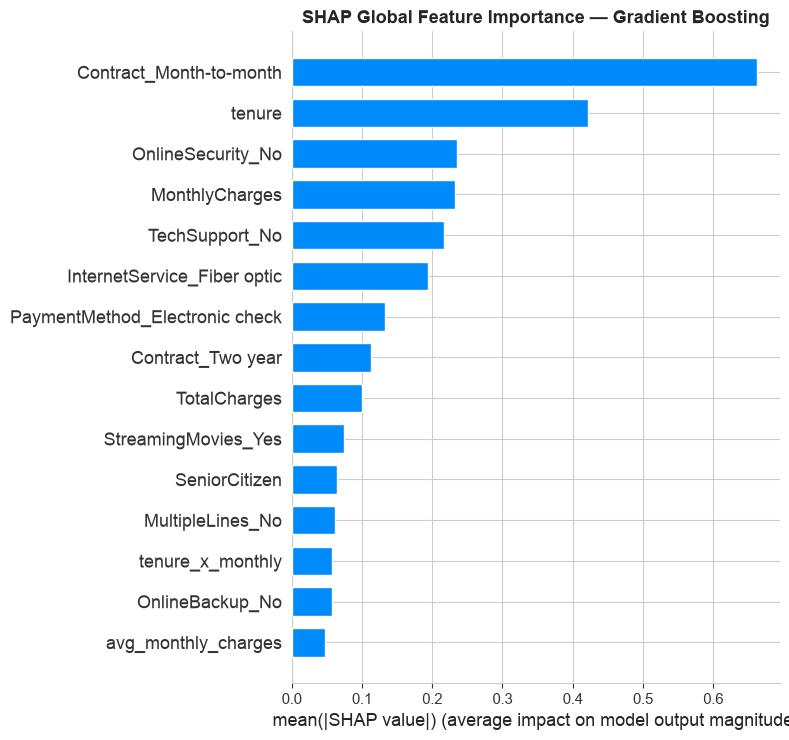

SHAP bar plot saved to: ../results/shap_feature_importance.png


In [14]:
# Compute SHAP values for the best model on the test set
print("=== Computing SHAP Values ===")

import shap

# TreeExplainer is exact and fast for tree ensembles (Gradient Boosting here).
explainer = shap.TreeExplainer(best_model)
shap_raw = explainer.shap_values(X_test_features)

# Normalize output to a 2-D array (n_samples, n_features) for the positive (churn) class.
# Different sklearn/shap versions return either a list [neg, pos] or a 3-D array.
if isinstance(shap_raw, list):
    shap_values = np.asarray(shap_raw[1])
else:
    shap_values = np.asarray(shap_raw)
    if shap_values.ndim == 3:  # (n_samples, n_features, n_classes)
        shap_values = shap_values[:, :, 1]

print(f"SHAP values shape: {shap_values.shape}  (n_samples, n_features)")
print(f"Explained model: {best_model_name} on {X_test_features.shape[0]} test customers")

# Global SHAP feature importance (bar plot, ranked by mean |SHAP|)
plt.figure()
shap.summary_plot(shap_values, X_test_features, plot_type='bar', max_display=15, show=False)
plt.title(f'SHAP Global Feature Importance — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'shap_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"SHAP bar plot saved to: {RESULTS_DIR / 'shap_feature_importance.png'}")

=== SHAP Summary Plot & Top Churn Drivers ===


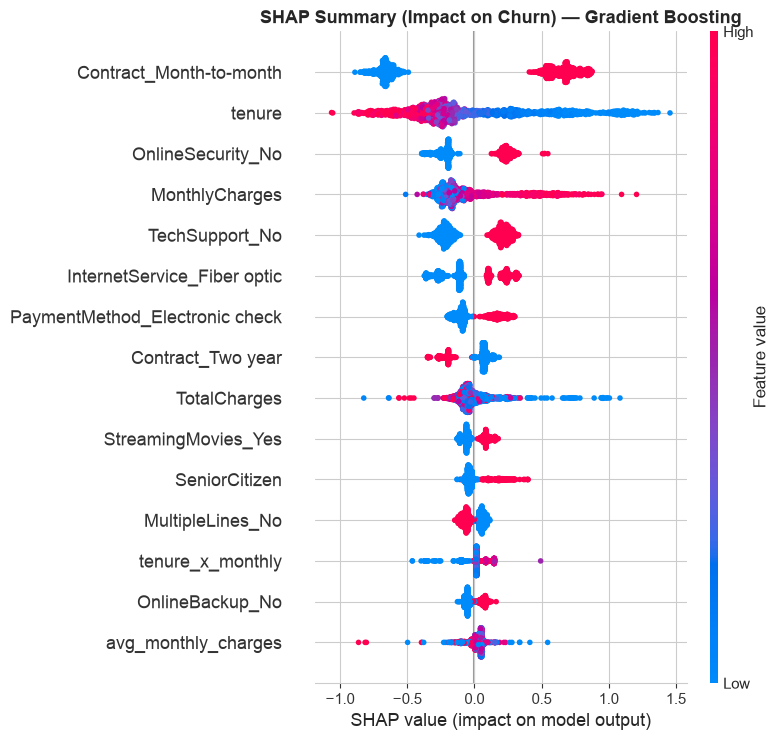

SHAP summary plot saved to: ../results/shap_summary.png

Top 10 features by mean |SHAP|:
                       feature  mean_abs_shap       direction
       Contract_Month-to-month       0.661886 increases churn
                        tenure       0.421859   reduces churn
             OnlineSecurity_No       0.235286 increases churn
                MonthlyCharges       0.231913 increases churn
                TechSupport_No       0.216976 increases churn
   InternetService_Fiber optic       0.194618 increases churn
PaymentMethod_Electronic check       0.133111 increases churn
             Contract_Two year       0.112509   reduces churn
                  TotalCharges       0.099766   reduces churn
           StreamingMovies_Yes       0.074300 increases churn

=== Top 5 Churn Drivers ===
1. Contract_Month-to-month          mean|SHAP|=0.6619  ->  increases churn
2. tenure                           mean|SHAP|=0.4219  ->  reduces churn
3. OnlineSecurity_No                mean|SHAP|=0.235

/Users/b/data/projects/telco-churn-analytics/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/b/data/projects/telco-churn-analytics/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [15]:
# SHAP summary (beeswarm) plot + top-5 churn drivers with direction
print("=== SHAP Summary Plot & Top Churn Drivers ===")

# Beeswarm: magnitude + direction of each feature's impact across all customers.
plt.figure()
shap.summary_plot(shap_values, X_test_features, max_display=15, show=False)
plt.title(f'SHAP Summary (Impact on Churn) — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"SHAP summary plot saved to: {RESULTS_DIR / 'shap_summary.png'}")

# Rank features by mean |SHAP| and determine direction of each top driver.
# Direction = sign of correlation between the feature's value and its SHAP value:
#   positive corr -> higher feature value pushes the prediction toward churn.
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = (
    pd.DataFrame({'feature': X_test_features.columns, 'mean_abs_shap': mean_abs_shap})
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

directions = []
for feat in shap_importance['feature']:
    col_idx = X_test_features.columns.get_loc(feat)
    feat_vals = X_test_features[feat].to_numpy()
    if np.std(feat_vals) == 0:
        directions.append('n/a')
        continue
    corr = np.corrcoef(feat_vals, shap_values[:, col_idx])[0, 1]
    directions.append('increases churn' if corr > 0 else 'reduces churn')
shap_importance['direction'] = directions

print("\nTop 10 features by mean |SHAP|:")
print(shap_importance.head(10).to_string(index=False))

print("\n=== Top 5 Churn Drivers ===")
for i, (_, row) in enumerate(shap_importance.head(5).iterrows()):
    print(f"{i + 1}. {row['feature']:<32} mean|SHAP|={row['mean_abs_shap']:.4f}  ->  {row['direction']}")

In [16]:
# Save analysis results
print("=== Saving Analysis Results ===")

# Save analysis dataframe
analysis_df.to_csv(RESULTS_DIR / 'prediction_analysis.csv', index=False)
print(f"Prediction analysis saved to: {RESULTS_DIR / 'prediction_analysis.csv'}")

# Top 5 churn drivers (from SHAP) for the report
top5_drivers = "\n".join(
    f"{i + 1}. {row['feature']} ({row['direction']}, mean|SHAP|={row['mean_abs_shap']:.4f})"
    for i, (_, row) in enumerate(shap_importance.head(5).iterrows())
)

# Create summary report
summary_report = f"""
# Telco Churn Prediction - Model Results Summary

## Best Model
- Model: {best_model_name}
- Test ROC-AUC: {results_df.loc[best_model_name, 'test_roc_auc']:.4f}
- Test Accuracy: {results_df.loc[best_model_name, 'test_accuracy']:.4f}
- Test Precision: {results_df.loc[best_model_name, 'test_precision']:.4f}
- Test Recall: {results_df.loc[best_model_name, 'test_recall']:.4f}
- Test F1 Score: {results_df.loc[best_model_name, 'test_f1']:.4f}

## Model Comparison
{results_df.round(4).to_string()}

## Key Findings
- Best performing model: {best_model_name}
- All models achieved ROC-AUC > 0.5
- Optimal classification threshold: {optimal_threshold:.4f}
- Consider class imbalance handling for further improvement

## Top 5 Churn Drivers (SHAP)
{top5_drivers}

## Generated Visualizations
- model_performance_dashboard.png
- model_radar_chart.png
- probability_distribution.png
- confusion_matrix.png
- roc_curve.png
- feature_importance.png
- shap_feature_importance.png
- shap_summary.png
"""

with open(RESULTS_DIR / 'summary_report.md', 'w') as f:
    f.write(summary_report)

print(f"Summary report saved to: {RESULTS_DIR / 'summary_report.md'}")

=== Saving Analysis Results ===
Prediction analysis saved to: ../results/prediction_analysis.csv
Summary report saved to: ../results/summary_report.md


In [ ]:
# Interactive 3D Customer Segmentation with Plotly
print("=== Interactive 3D Customer Segmentation ===")

try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    
    # Select key features for 3D visualization
    # Try engineered features first, fall back to basic features
    if 'clv_proxy' in X_test_features.columns:
        feature_cols = ['tenure', 'MonthlyCharges', 'clv_proxy']
        feature_names = ['Tenure (months)', 'Monthly Charges ($)', 'Customer Lifetime Value ($)']
    elif 'tenure_x_monthly' in X_test_features.columns:
        feature_cols = ['tenure', 'MonthlyCharges', 'tenure_x_monthly']
        feature_names = ['Tenure (months)', 'Monthly Charges ($)', 'Tenure × Monthly Charges']
    else:
        feature_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
        feature_names = ['Tenure (months)', 'Monthly Charges ($)', 'Total Charges ($)']
    
    # Create segmentation dataframe
    seg_df = X_test_features[feature_cols].copy()
    seg_df['actual_churn'] = y_test
    seg_df['churn_probability'] = y_test_proba
    seg_df['customerID'] = customer_id_test
    
    # Define risk levels
    seg_df['risk_level'] = pd.cut(
        y_test_proba, 
        bins=[0, 0.3, 0.7, 1.0], 
        labels=['Low Risk', 'Medium Risk', 'High Risk']
    )
    
    # Create 3D scatter plot
    fig_3d = px.scatter_3d(
        seg_df,
        x=feature_cols[0],
        y=feature_cols[1],
        z=feature_cols[2],
        color='risk_level',
        symbol='actual_churn',
        size='churn_probability',
        hover_data={
            'customerID': True,
            'churn_probability': ':.3f',
            'actual_churn': True,
            'risk_level': True
        },
        title=f'<b>3D Customer Segmentation</b><br><sub>{feature_names[0]} vs {feature_names[1]} vs {feature_names[2]}</sub>',
        color_discrete_map={
            'Low Risk': '#2E8B57',      # Sea green
            'Medium Risk': '#FFD700',   # Gold  
            'High Risk': '#DC143C'      # Crimson
        },
        opacity=0.8
    )
    
    # Update layout for better visualization
    fig_3d.update_traces(
        marker=dict(
            line=dict(width=1, color='DarkSlateGrey'),
            size=8
        ),
        selector=dict(mode='markers')
    )
    
    fig_3d.update_layout(
        scene=dict(
            xaxis_title=feature_names[0],
            yaxis_title=feature_names[1],
            zaxis_title=feature_names[2],
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.5)
            )
        ),
        height=700,
        legend=dict(
            title_text='Risk Level / Churn Status',
            itemsizing='constant'
        ),
        hoverlabel=dict(
            bgcolor="white",
            font_size=12,
            font_family="Arial"
        )
    )
    
    # Save interactive plot
    fig_3d.write_html(str(RESULTS_DIR / 'interactive_3d_segmentation.html'))
    print(f"Interactive 3D segmentation saved to: {RESULTS_DIR / 'interactive_3d_segmentation.html'}")
    
    # Display statistics
    print(f"\n3D Segmentation Statistics:")
    print(f"Features used: {feature_cols}")
    print(f"Risk distribution:")
    print(seg_df['risk_level'].value_counts())
    print(f"\nActual churn by risk level:")
    risk_churn = seg_df.groupby('risk_level')['actual_churn'].agg(['count', 'sum', 'mean'])
    risk_churn.columns = ['Total Customers', 'Churned', 'Churn Rate']
    print(risk_churn.round(3))
    
    # Show the plot (if in notebook environment)
    fig_3d.show()
    
except ImportError:
    print("Plotly not installed. Install with: pip install -e '.[interactive]'")

print("\n=== Interactive SHAP Feature Dashboard ===")

try:
    # Create interactive SHAP dashboard
    shap_df = pd.DataFrame(shap_values, columns=X_test_features.columns)
    
    # Calculate mean absolute SHAP values for ranking
    mean_abs_shap = np.abs(shap_df).mean().sort_values(ascending=False)
    top_features = mean_abs_shap.head(15).index.tolist()
    
    # Create subplots for SHAP analysis
    fig_shap = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            'Top 15 Features by Mean |SHAP|',
            'SHAP Values Distribution (Top 5)',
            'Feature Value vs SHAP Impact',
            'Customer-Level SHAP Breakdown'
        ),
        specs=[
            [{"type": "bar"}, {"type": "box"}],
            [{"type": "scatter"}, {"type": "bar"}]
        ]
    )
    
    # 1. Feature importance bar chart
    fig_shap.add_trace(
        go.Bar(
            x=mean_abs_shap.head(15).values,
            y=mean_abs_shap.head(15).index,
            orientation='h',
            name='Mean |SHAP|',
            marker_color='steelblue',
            hovertemplate='<b>%{y}</b><br>Mean |SHAP|: %{x:.4f}<extra></extra>'
        ),
        row=1, col=1
    )
    
    # 2. SHAP values distribution for top 5 features
    top5 = mean_abs_shap.head(5).index.tolist()
    for feature in top5:
        fig_shap.add_trace(
            go.Box(
                y=shap_df[feature],
                name=feature,
                hovertemplate=f'<b>{feature}</b><br>SHAP Value: %{{y:.4f}}<extra></extra>'
            ),
            row=1, col=2
        )

    # 3. Feature value vs SHAP impact for top feature
    top_feature = mean_abs_shap.index[0]
    feature_values = X_test_features[top_feature]
    shap_values_feature = shap_df[top_feature]

    # Add trend line
    fig_shap.add_trace(
        go.Scatter(
            x=feature_values,
            y=shap_values_feature,
            mode='markers',
            name=f'{top_feature}',
            opacity=0.6,
            hovertemplate=f'<b>{top_feature}</b><br>Feature Value: %{{x:.3f}}<br>SHAP Value: %{{y:.4f}}<extra></extra>'
        ),
        row=2, col=1
    )

    # 4. Customer-level SHAP breakdown (sample customers)
    sample_customers = np.random.choice(len(shap_df), min(5, len(shap_df)), replace=False)
    sample_shap = shap_df.iloc[sample_customers, top5]

    for i, customer_idx in enumerate(sample_customers):
        fig_shap.add_trace(
            go.Bar(
                x=top5,
                y=sample_shap.iloc[i],
                name=f'Customer {customer_idx}',
                hovertemplate='<b>%{x}</b><br>SHAP: %{y:.4f}<extra></extra>'
            ),
            row=2, col=2
        )

    # Update layout
    fig_shap.update_layout(
        title='<b>Interactive SHAP Feature Analysis Dashboard</b>',
        height=800,
        showlegend=True,
        hovermode='closest'
    )

    # Update subplot layouts
    fig_shap.update_xaxes(title_text="Mean |SHAP|", row=1, col=1)
    fig_shap.update_yaxes(title_text="Feature", row=1, col=1)

    fig_shap.update_xaxes(title_text="", row=1, col=2)
    fig_shap.update_yaxes(title_text="SHAP Value", row=1, col=2)

    fig_shap.update_xaxes(title_text=f"Feature Value ({top_feature})", row=2, col=1)
    fig_shap.update_yaxes(title_text="SHAP Value", row=2, col=1)

    fig_shap.update_xaxes(title_text="Feature", row=2, col=2)
    fig_shap.update_yaxes(title_text="SHAP Value", row=2, col=2)

    # Save interactive SHAP dashboard
    fig_shap.write_html(str(RESULTS_DIR / 'interactive_shap_dashboard.html'))
    print(f"Interactive SHAP dashboard saved to: {RESULTS_DIR / 'interactive_shap_dashboard.html'}")

    # Display the dashboard
    fig_shap.show()

    print(f"\nSHAP Dashboard Summary:")
    print(f"Total features analyzed: {len(mean_abs_shap)}")
    print(f"Top feature: {top_feature} (mean |SHAP|: {mean_abs_shap.iloc[0]:.4f})")
    print(f"SHAP value range: [{shap_df.values.min():.4f}, {shap_df.values.max():.4f}]")

except Exception as e:
    print(f"Error creating SHAP dashboard: {e}")

print("\n=== Interactive Probability Distribution ===")

try:
    # Create interactive probability distribution
    fig_prob = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            'Overall Probability Distribution',
            'Probability by Actual Churn',
            'Risk Segmentation',
            'Threshold Impact Analysis'
        ),
        specs=[
            [{"type": "histogram"}, {"type": "violin"}],
            [{"type": "pie"}, {"type": "scatter"}]
        ]
    )

    # 1. Overall probability distribution
    fig_prob.add_trace(
        go.Histogram(
            x=y_test_proba,
            nbinsx=50,
            name='Churn Probability',
            opacity=0.7,
            marker_color='skyblue',
            hovertemplate='Probability Range: %{x}<br>Count: %{y}<extra></extra>'
        ),
        row=1, col=1
    )

    # 2. Probability by actual churn (violin plot)
    fig_prob.add_trace(
        go.Violin(
            x=y_test[y_test == 0],
            y=y_test_proba[y_test == 0],
            name='No Churn',
            side='negative',
            fillcolor='lightgreen',
            opacity=0.7,
            hovertemplate='No Churn<br>Probability: %{y:.3f}<extra></extra>'
        ),
        row=1, col=2
    )

    fig_prob.add_trace(
        go.Violin(
            x=y_test[y_test == 1],
            y=y_test_proba[y_test == 1],
            name='Churn',
            side='positive',
            fillcolor='lightcoral',
            opacity=0.7,
            hovertemplate='Churn<br>Probability: %{y:.3f}<extra></extra>'
        ),
        row=1, col=2
    )

    # 3. Risk segmentation pie chart
    risk_counts = seg_df['risk_level'].value_counts()
    fig_prob.add_trace(
        go.Pie(
            labels=risk_counts.index,
            values=risk_counts.values,
            name='Risk Segments',
            hole=0.3,
            marker_colors=['#2E8B57', '#FFD700', '#DC143C'],
            hovertemplate='<b>%{label}</b><br>Count: %{value}<br>Percentage: %{percent}<extra></extra>'
        ),
        row=2, col=1
    )

    # 4. Threshold impact analysis
    thresholds = np.arange(0.1, 0.91, 0.05)
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for threshold in thresholds:
        y_pred = (y_test_proba >= threshold).astype(int)
        precision_scores.append(precision_score(y_test, y_pred))
        recall_scores.append(recall_score(y_test, y_pred))
        f1_scores.append(f1_score(y_test, y_pred))

    fig_prob.add_trace(
        go.Scatter(
            x=thresholds,
            y=precision_scores,
            mode='lines+markers',
            name='Precision',
            line=dict(color='blue'),
            hovertemplate='Threshold: %{x:.2f}<br>Precision: %{y:.3f}<extra></extra>'
        ),
        row=2, col=2
    )

    fig_prob.add_trace(
        go.Scatter(
            x=thresholds,
            y=recall_scores,
            mode='lines+markers',
            name='Recall',
            line=dict(color='green'),
            hovertemplate='Threshold: %{x:.2f}<br>Recall: %{y:.3f}<extra></extra>'
        ),
        row=2, col=2
    )

    fig_prob.add_trace(
        go.Scatter(
            x=thresholds,
            y=f1_scores,
            mode='lines+markers',
            name='F1 Score',
            line=dict(color='red', width=3),
            hovertemplate='Threshold: %{x:.2f}<br>F1: %{y:.3f}<extra></extra>'
        ),
        row=2, col=2
    )

    # Update layout
    fig_prob.update_layout(
        title='<b>Interactive Probability Analysis Dashboard</b>',
        height=800,
        showlegend=True,
        hovermode='closest'
    )

    # Update subplot layouts
    fig_prob.update_xaxes(title_text="Churn Probability", row=1, col=1)
    fig_prob.update_yaxes(title_text="Count", row=1, col=1)

    fig_prob.update_xaxes(title_text="Actual Churn", row=1, col=2)
    fig_prob.update_yaxes(title_text="Churn Probability", row=1, col=2)

    fig_prob.update_xaxes(title_text="", row=2, col=1)
    fig_prob.update_yaxes(title_text="", row=2, col=1)

    fig_prob.update_xaxes(title_text="Threshold", row=2, col=2)
    fig_prob.update_yaxes(title_text="Score", row=2, col=2)

    # Save interactive probability dashboard
    fig_prob.write_html(str(RESULTS_DIR / 'interactive_probability_dashboard.html'))
    print(f"Interactive probability dashboard saved to: {RESULTS_DIR / 'interactive_probability_dashboard.html'}")

    # Display the dashboard
    fig_prob.show()

    print(f"\nProbability Analysis Summary:")
    print(f"Probability range: [{y_test_proba.min():.3f}, {y_test_proba.max():.3f}]")
    print(f"Mean probability: {y_test_proba.mean():.3f}")
    print(f"Optimal threshold (max F1): {thresholds[np.argmax(f1_scores)]:.2f}")

except Exception as e:
    print(f"Error creating probability dashboard: {e}")

print("\n=== Interactive Visualizations Complete ===")
print("Generated interactive dashboards:")
print(f"  - 3D Customer Segmentation")
print(f"  - SHAP Feature Analysis") 
print(f"  - Probability Distribution")
print(f"\nAll saved as HTML files for interactive viewing")

=== Interactive 3D Customer Segmentation ===
Plotly not installed. Install with: pip install -e '.[interactive]'

=== Interactive SHAP Feature Dashboard ===
Error creating SHAP dashboard: name 'make_subplots' is not defined

=== Interactive Probability Distribution ===
Error creating probability dashboard: name 'make_subplots' is not defined

=== Interactive Visualizations Complete ===
Generated interactive dashboards:
  - 3D Customer Segmentation
  - SHAP Feature Analysis
  - Probability Distribution

All saved as HTML files for interactive viewing
